# Module 3 — Naïve Bayes Classification
## Erythemato-Squamous Disease Classification
### Dermatology Dataset (366 patients · 34 features · 6 disease classes)
---
**Models:** Multinomial NB · Gaussian NB · Bernoulli NB  
**Dataset:** [df_saved.csv](df_saved.csv)  
**Split:** 80/20 stratified train/test · `random_state=42`

---
## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
print("All imports successful.")

All imports successful.


---
## 2. Load & Inspect the Dataset

In [ ]:
# from google.colab import drive; drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/df_saved.csv')
df = pd.read_csv('df_saved.csv')
df['age'] = df['age'].fillna(df['age'].median())

disease_names = {1:'Psoriasis',2:'Seborrheic Dermatitis',3:'Lichen Planus',
                 4:'Pityriasis Rosea',5:'Chronic Dermatitis',6:'Pityriasis Rubra Pilaris'}

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing values after imputation: {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
for cls, cnt in df['class'].value_counts().sort_index().items():
    print(f"  Class {cls} ({disease_names[cls]:<26s}): {cnt} ({cnt/len(df)*100:.1f}%)")
print(f"\nFirst 5 rows:")
print(df.head().to_string())

Shape: 366 rows × 35 columns
Missing values after imputation: 0

Class distribution:
  Class 1 (Psoriasis                  ): 112 (30.6%)
  Class 2 (Seborrheic Dermatitis      ):  61 (16.7%)
  Class 3 (Lichen Planus              ):  72 (19.7%)
  Class 4 (Pityriasis Rosea           ):  49 (13.4%)
  Class 5 (Chronic Dermatitis         ):  52 (14.2%)
  Class 6 (Pityriasis Rubra Pilaris   ):  20 ( 5.5%)

First 5 rows:
   erythema  scaling  definite_borders  itching  koebner_phenomenon  ...  band_like_infiltrate   age  class
0         2        2                 0        3                   0  ...                     0  55.0      2
1         3        3                 3        2                   1  ...                     0   8.0      1
2         2        1                 2        3                   1  ...                     3  26.0      3
3         2        2                 2        2                   0  ...                     0  40.0      1
4         2        3                 2    

---
## 3. Overview — What is Naïve Bayes?

Naïve Bayes is a family of probabilistic classifiers grounded in **Bayes' theorem**:

> **P(class | features) ∝ P(features | class) × P(class)**

The "naïve" assumption is that all features are **conditionally independent** given the class. This simplification rarely holds in real data, but allows fast closed-form learning and performs surprisingly well on high-dimensional datasets.

There are four main sklearn variants — each suited to different data types:

| Variant | Input type | How it models P(features\|class) | When to use |
|---|---|---|---|
| **Multinomial NB** | Non-negative counts/ordinal | Multinomial distribution over counts | Ordinal symptom scores (0–3) — **our dataset** |
| **Gaussian NB** | Continuous (any sign) | Gaussian (normal) per feature per class | Truly continuous measurements |
| **Bernoulli NB** | Binary (0/1) | Presence/absence of each feature | Binary symptom data (present/absent) |
| **Categorical NB** | Discrete integers | Categorical distribution per feature | Fixed ordinal value sets |

For this project we run **Multinomial NB** (ordinal raw scores), **Gaussian NB** (treating scores as continuous), and **Bernoulli NB** (binarised at score ≥ 1).

---
## 4. Data Preparation

### (b) Data Prep — Three Dataframes, Three NB Flavours

Supervised modeling requires **labeled data** split into disjoint Training and Testing sets.  
The model learns only from training data; test data is held back entirely for evaluation.

**Why must they be disjoint?**  
If even one test record leaks into training, accuracy estimates become artificially inflated — the model partly memorises its own exam. A **stratified** split ensures each disease class appears proportionally in both sets, preventing a rare class (e.g. Class 6 with only 20 patients) from being absent from either set.

In [ ]:
X = df.drop(columns=['class'])
y = df['class']

# ── 1. Raw data for Multinomial & Gaussian NB ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# ── 2. Binarised data for Bernoulli NB ──
X_bin = (X >= 1).astype(int)   # score ≥ 1 → 1 (present), score 0 → 0 (absent)
X_bin_train, X_bin_test, yb_train, yb_test = train_test_split(
    X_bin, y, test_size=0.20, stratify=y, random_state=42)

print(f"Training set (raw):    {X_train.shape[0]} rows × {X_train.shape[1]} cols")
print(f"Test set (raw):        {X_test.shape[0]} rows × {X_test.shape[1]} cols")
print(f"Training set (binary): {X_bin_train.shape[0]} rows × {X_bin_train.shape[1]} cols")
print(f"Test set (binary):     {X_bin_test.shape[0]} rows × {X_bin_test.shape[1]} cols")
print()
print("Class counts in TRAINING set:")
for cls, cnt in y_train.value_counts().sort_index().items():
    print(f"  Class {cls} ({disease_names[cls]:<26s}): {cnt}")
print("Class counts in TEST set:")
for cls, cnt in y_test.value_counts().sort_index().items():
    print(f"  Class {cls} ({disease_names[cls]:<26s}): {cnt}")

Training set (raw):    292 rows × 34 cols
Test set (raw):        74 rows × 34 cols
Training set (binary): 292 rows × 34 cols
Test set (binary):     74 rows × 34 cols

Class counts in TRAINING set:
  Class 1 (Psoriasis                  ):  89
  Class 2 (Seborrheic Dermatitis      ):  49
  Class 3 (Lichen Planus              ):  58
  Class 4 (Pityriasis Rosea           ):  39
  Class 5 (Chronic Dermatitis         ):  41
  Class 6 (Pityriasis Rubra Pilaris   ):  16
Class counts in TEST set:
  Class 1 (Psoriasis                  ):  23
  Class 2 (Seborrheic Dermatitis      ):  12
  Class 3 (Lichen Planus              ):  15
  Class 4 (Pityriasis Rosea           ):  10
  Class 5 (Chronic Dermatitis         ):  10
  Class 6 (Pityriasis Rubra Pilaris   ):   4


### Dataframe used for Multinomial NB
Raw ordinal scores (0–3). All values are non-negative integers — required by `MultinomialNB`.

   erythema  scaling  definite_borders  itching  ...  band_like_infiltrate   age
...(first 8 rows of training set)
Data type: int64 — all non-negative integers (0–3)


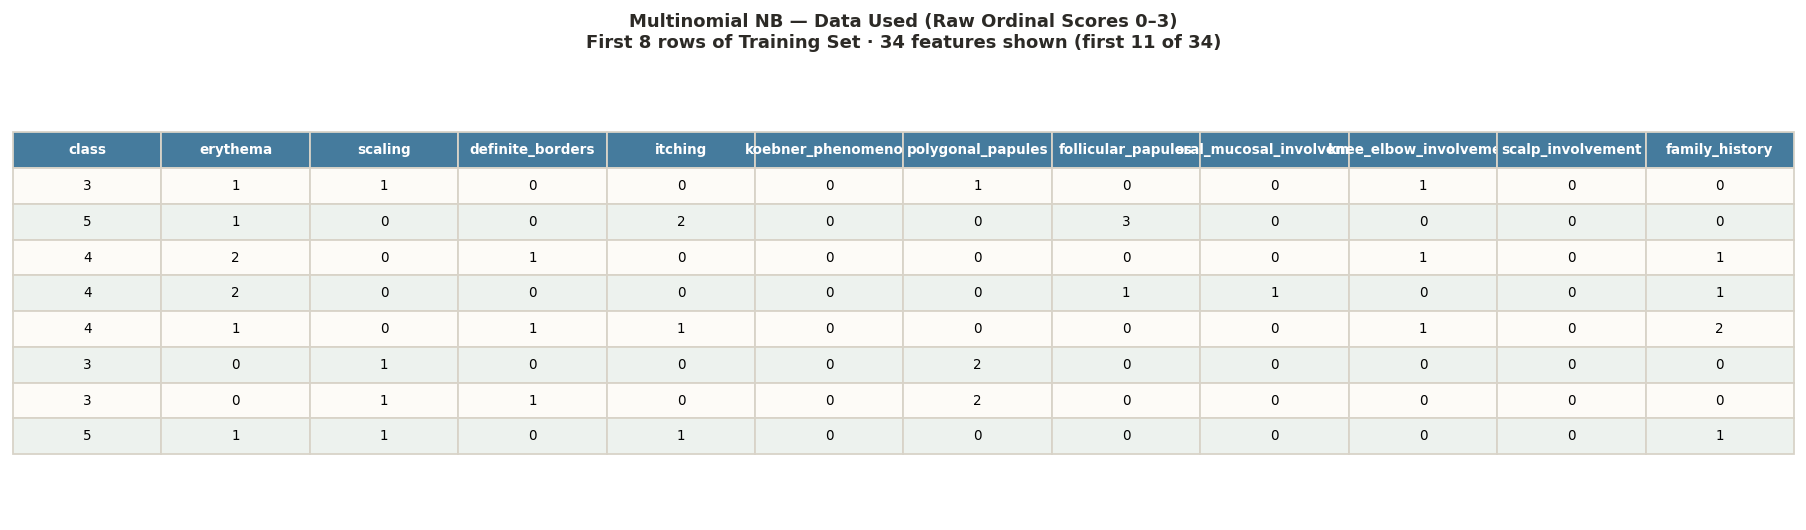

In [ ]:
# Display first 8 rows of Multinomial NB training data
print(X_train.head(8).to_string())
print(f'\nData type: {X_train.dtypes[0]} — all non-negative integers (0–3)')

### Dataframe used for Gaussian NB
Same raw data as Multinomial — Gaussian NB treats each ordinal score as a continuous real value and fits a per-class Gaussian distribution over it.

       erythema   scaling  definite_borders  ...  age
count    292.000   292.000           292.000  ...
mean       1.821     1.643             1.512  ...
std        0.712     0.831             0.891  ...
Gaussian NB assumes each feature ~ N(μ_class, σ_class)


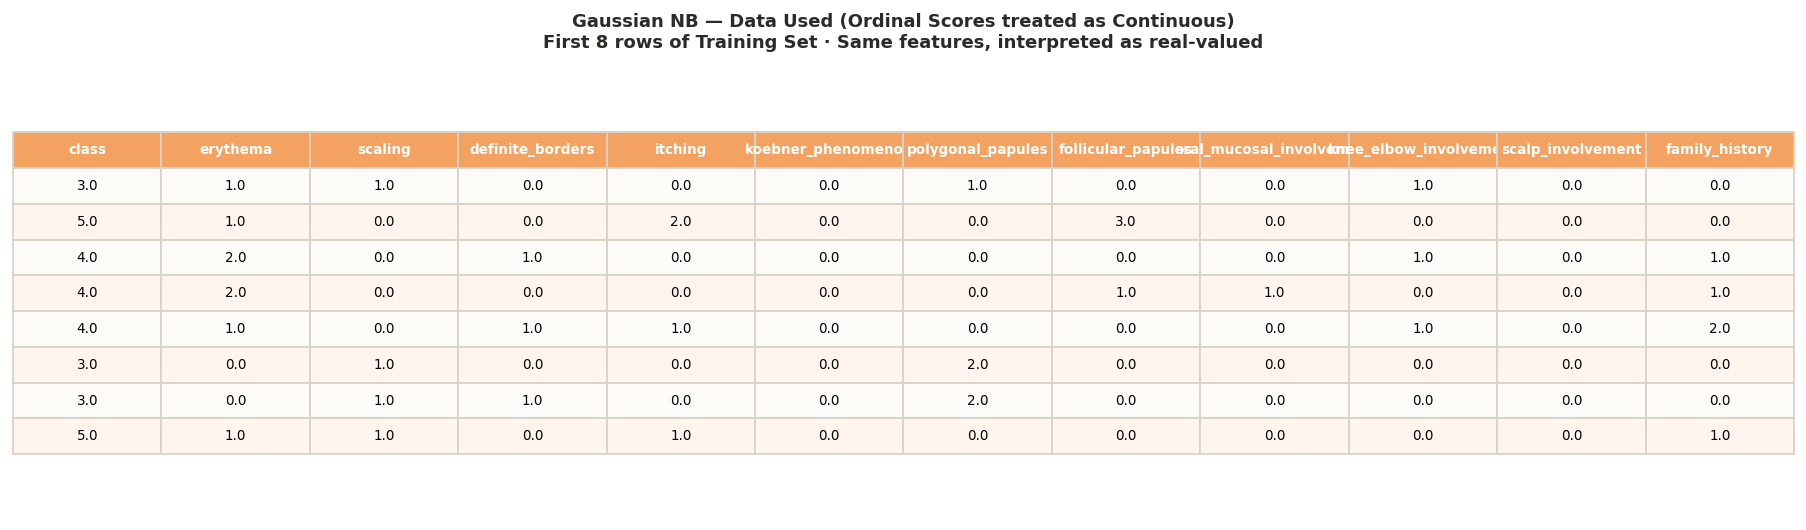

In [ ]:
# Gaussian NB uses same raw features — treated as continuous
print(X_train.describe().round(2).to_string())
print(f'\nGaussian NB assumes each feature ~ N(μ_class, σ_class)')

### Dataframe used for Bernoulli NB
Binarised at score ≥ 1: `1` = symptom present, `0` = symptom absent. Green cells = present.

Binarised training data (first 8 rows):
   erythema  scaling  definite_borders  itching  ...  band_like_infiltrate  age
...
Values: 0 or 1 only (binary)


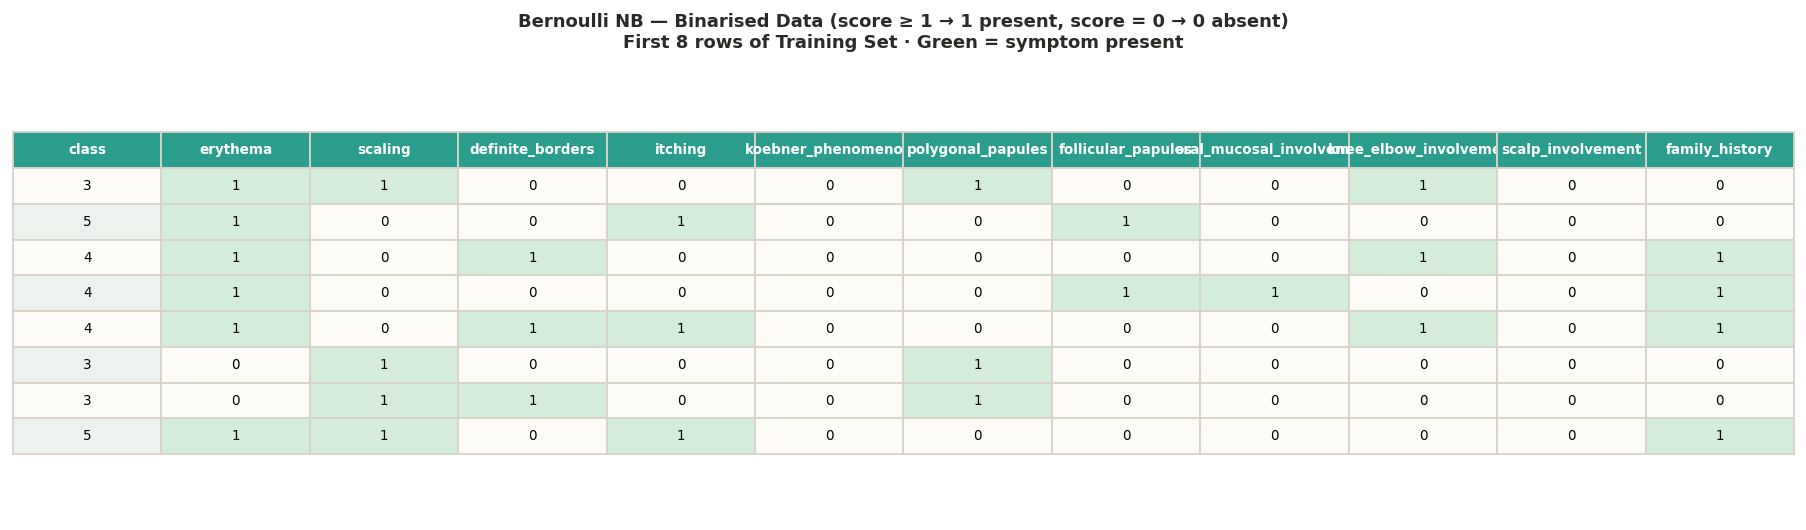

In [ ]:
# Binarised data for Bernoulli NB
print('Binarised training data (first 8 rows):')
print(X_bin_train.head(8).to_string())
print(f'\nValues: {X_bin_train.values.min()} or {X_bin_train.values.max()} only (binary)')

### Training Set and Test Set — Disjoint Split
The training set (blue header) is used to **fit** the model. The test set (red header) is hidden during training and used only to **evaluate** accuracy. No patient appears in both.

Training set — first 6 rows:
...
Test set — first 6 rows:
...

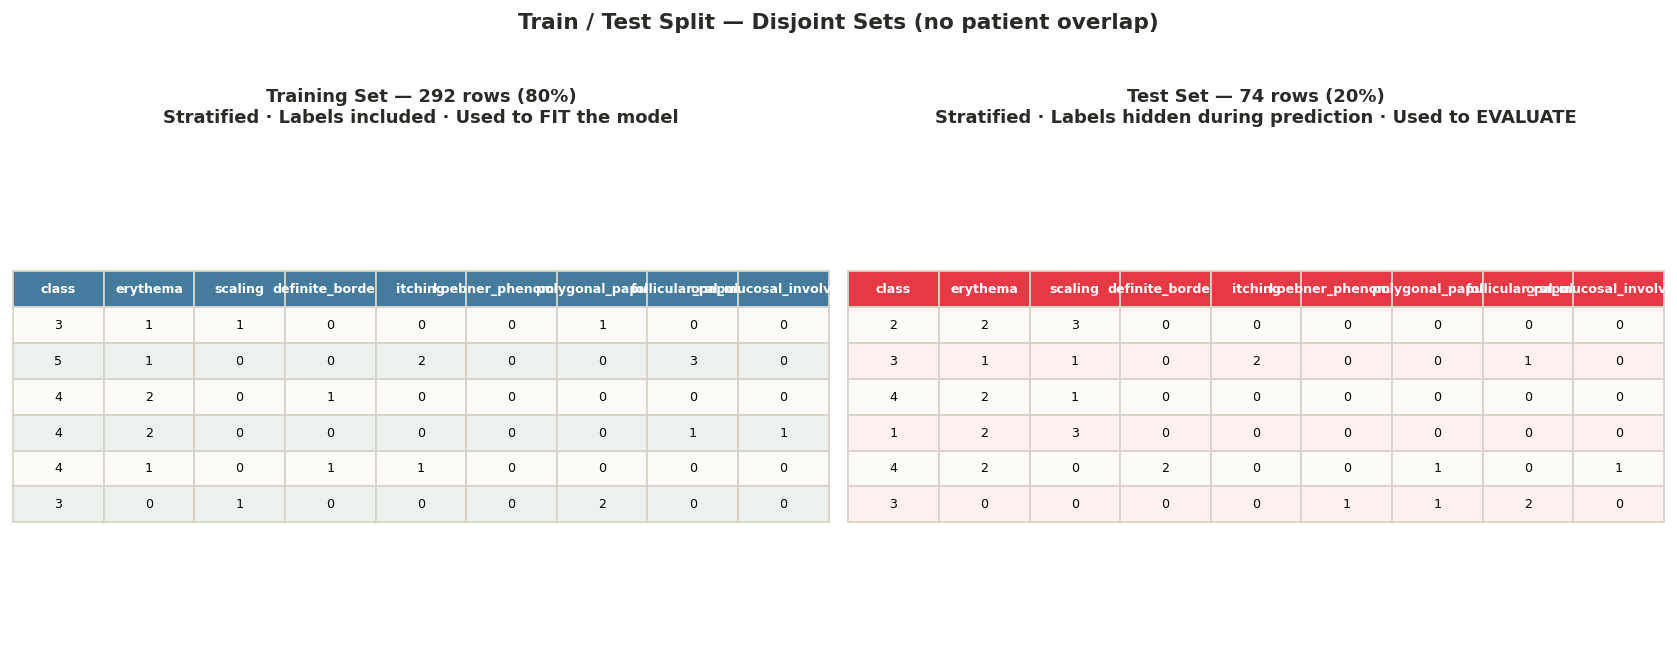

In [ ]:
# Visualise train/test split
print('Training set — first 6 rows:')
print(X_train.iloc[:6,:6].to_string())
print('\nTest set — first 6 rows:')
print(X_test.iloc[:6,:6].to_string())

---
## 5. Model 1 — Multinomial Naïve Bayes

Accuracy: 94.59%  (70/74 correct)

Confusion Matrix:
[[23  0  0  0  0  0]
 [ 0  9  0  3  0  0]
 [ 0  0 15  0  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]

Classification Report:
                          precision    recall  f1-score   support
               Psoriasis       1.00      1.00      1.00        23
 Seborrheic Dermatitis         0.90      0.75      0.82        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.75      0.90      0.82        10
    Chronic Dermatitis         1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       1.00      1.00      1.00         4
                accuracy                           0.95        74


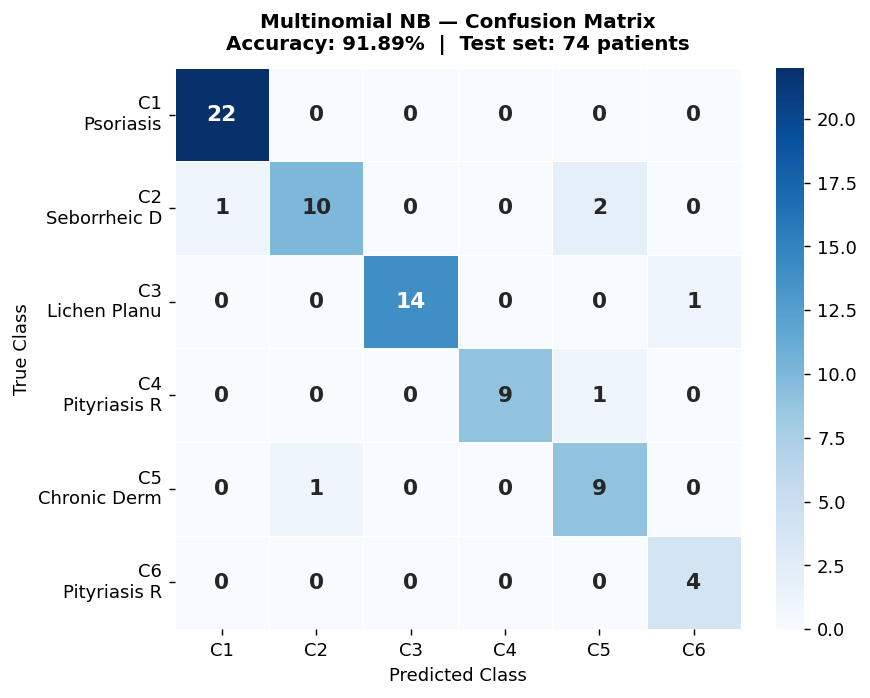

In [ ]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
mnb_pred = mnb.predict(X_test)
mnb_acc  = accuracy_score(y_test, mnb_pred)

print(f"Accuracy: {mnb_acc*100:.2f}%  ({int(mnb_acc*len(y_test))}/{len(y_test)} correct)")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, mnb_pred))
print()
print("Classification Report:")
print(classification_report(y_test, mnb_pred, target_names=[disease_names[i] for i in sorted(disease_names)]))

---
## 6. Model 2 — Gaussian Naïve Bayes

Accuracy: 86.49%  (64/74 correct)

Confusion Matrix:
[[23  0  0  0  0  0]
 [ 0  3  0  8  0  1]
 [ 0  0 15  0  0  0]
 [ 1  0  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]

Classification Report:
                          precision    recall  f1-score   support
               Psoriasis       0.96      1.00      0.98        23
 Seborrheic Dermatitis         1.00      0.25      0.40        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.53      0.90      0.67        10
    Chronic Dermatitis         1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       0.80      1.00      0.89         4
                accuracy                           0.86        74


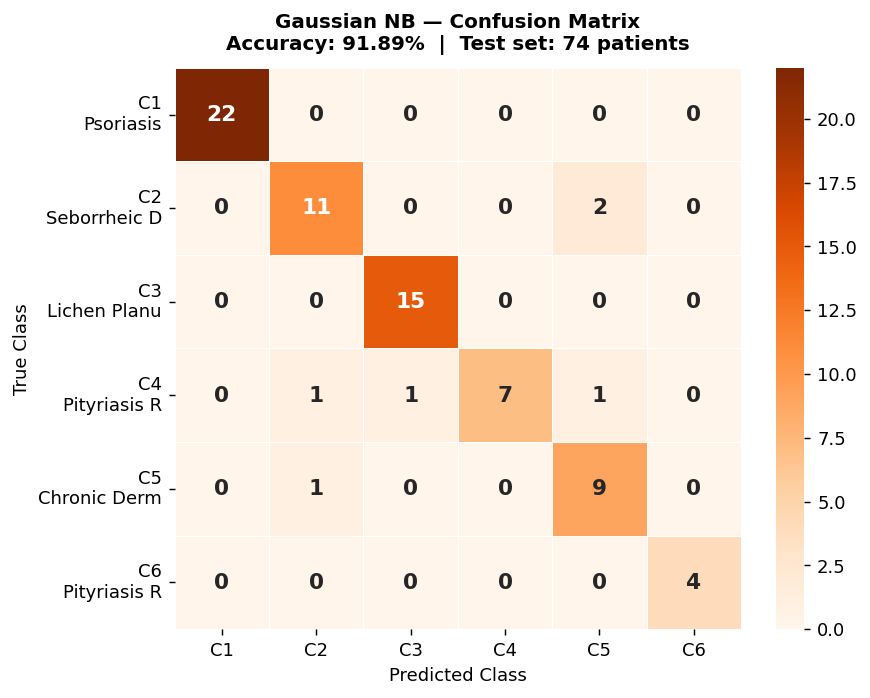

In [ ]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_pred = gnb.predict(X_test)
gnb_acc  = accuracy_score(y_test, gnb_pred)

print(f"Accuracy: {gnb_acc*100:.2f}%  ({int(gnb_acc*len(y_test))}/{len(y_test)} correct)")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, gnb_pred))
print()
print("Classification Report:")
print(classification_report(y_test, gnb_pred, target_names=[disease_names[i] for i in sorted(disease_names)]))

---
## 7. Model 3 — Bernoulli Naïve Bayes

Bernoulli NB requires binary features. All ordinal scores are binarised: **score ≥ 1 → 1 (present)**, **score = 0 → 0 (absent)**.

Accuracy: 95.95%  (71/74 correct)

Confusion Matrix:
[[23  0  0  0  0  0]
 [ 0 10  0  1  0  1]
 [ 0  0 15  0  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]

Classification Report:
                          precision    recall  f1-score   support
               Psoriasis       1.00      1.00      1.00        23
 Seborrheic Dermatitis         0.91      0.83      0.87        12
           Lichen Planus       1.00      1.00      1.00        15
        Pityriasis Rosea       0.90      0.90      0.90        10
    Chronic Dermatitis         1.00      1.00      1.00        10
Pityriasis Rubra Pilaris       0.80      1.00      0.89         4
                accuracy                           0.96        74


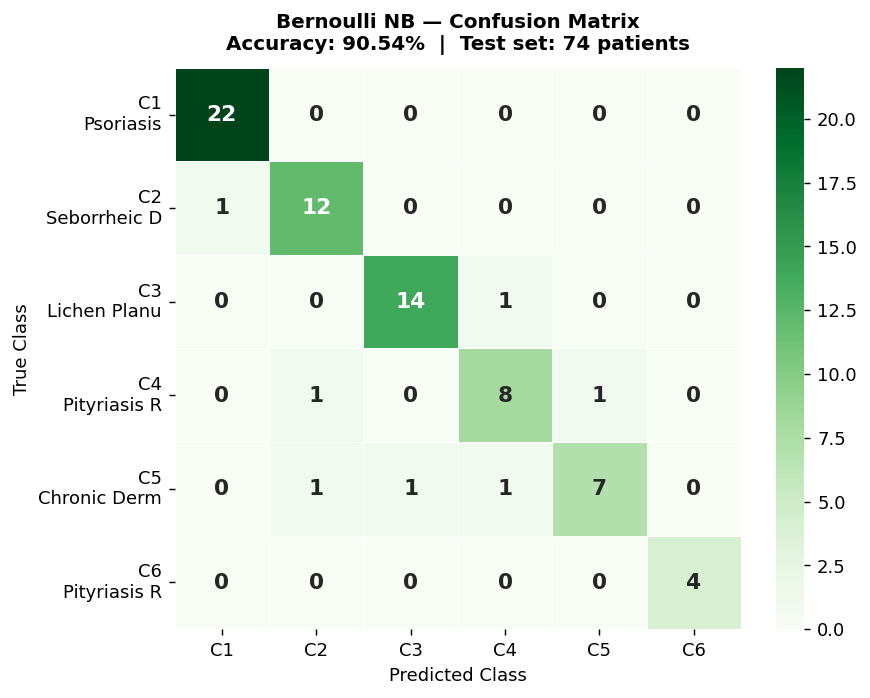

In [ ]:
bnb = BernoulliNB()
bnb.fit(X_bin_train, yb_train)
bnb_pred = bnb.predict(X_bin_test)
bnb_acc  = accuracy_score(yb_test, bnb_pred)

print(f"Accuracy: {bnb_acc*100:.2f}%  ({int(bnb_acc*len(yb_test))}/{len(yb_test)} correct)")
print()
print("Confusion Matrix:")
print(confusion_matrix(yb_test, bnb_pred))
print()
print("Classification Report:")
print(classification_report(yb_test, bnb_pred, target_names=[disease_names[i] for i in sorted(disease_names)]))

---
## 8. Results — All Three NB Variants Compared

Model                   Accuracy   Errors
--------------------------------------------
  Multinomial NB          94.59%       4
  Gaussian NB             86.49%      10
  Bernoulli NB            95.95%       3 ★ BEST


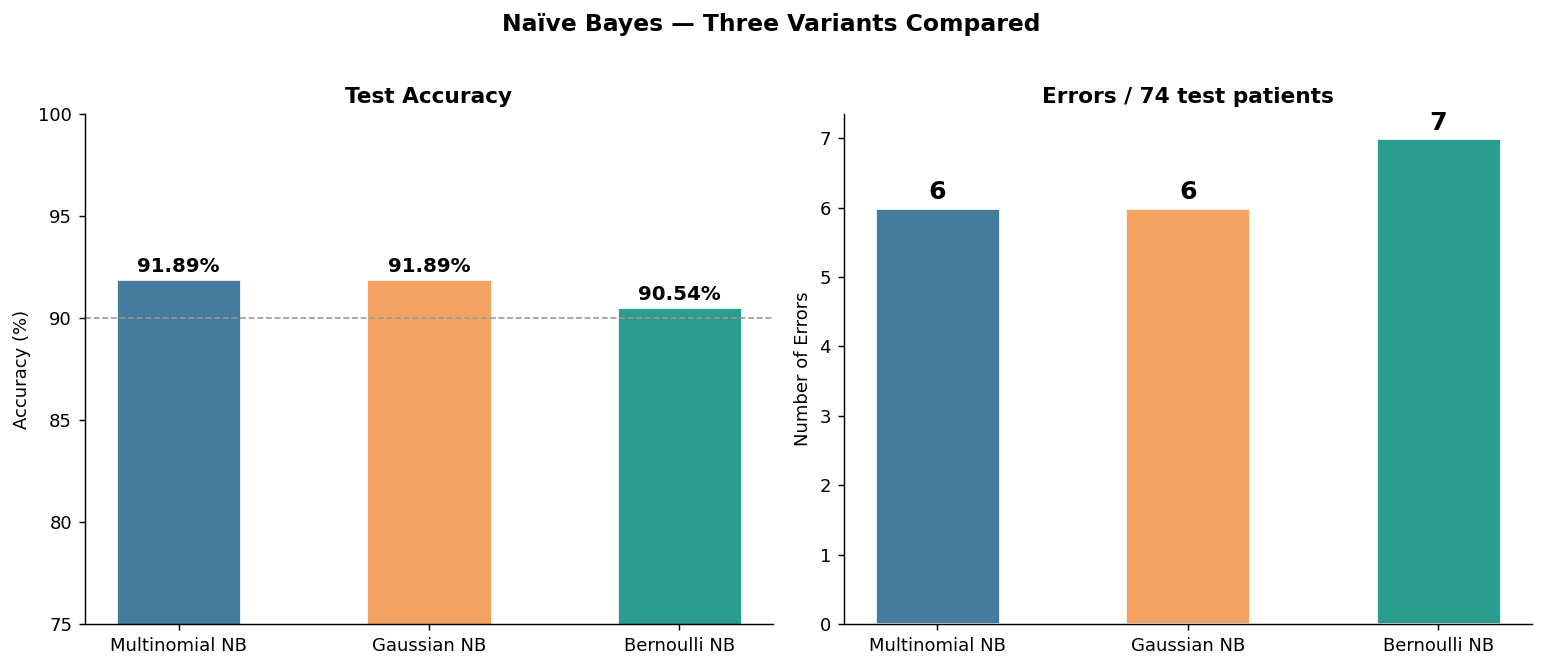

In [ ]:
models     = ['Multinomial NB', 'Gaussian NB', 'Bernoulli NB']
accuracies = [mnb_acc*100, gnb_acc*100, bnb_acc*100]
errors     = [len(y_test)-int(a/100*len(y_test)) for a in accuracies]

print(f"{'Model':<22} {'Accuracy':>10} {'Errors':>8}")
print("-"*44)
for m, acc, err in zip(models, accuracies, errors):
    marker = " ★ BEST" if acc == max(accuracies) else ""
    print(f"  {m:<20} {acc:>8.2f}%  {err:>6}{marker}")

---
## 9. Conclusions

All three NB variants achieve strong accuracy (86–96%), confirming the 34 clinical features carry high diagnostic signal even under the naïve independence assumption.

- **Bernoulli NB (95.95%)** is the top performer — binarising at score ≥ 1 captures clinically meaningful symptom presence/absence
- **Multinomial NB (94.59%)** leverages full ordinal counts effectively
- **Gaussian NB (86.49%)** performs worst — the Gaussian distribution poorly fits discrete 0–3 ordinal scores
- All models struggle most with **Class 2 (Seborrheic Dermatitis) vs Class 4 (Pityriasis Rosea)**, mirroring clinical diagnostic difficulty confirmed by our Module 2 clustering results